In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik uslubi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# ============================================================
# 1. DATASETNI YUKLASH
# ============================================================
df = pd.read_csv("data/SuperMarket.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
# ============================================================
# 2. UMUMIY MA'LUMOT
# ============================================================
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [4]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [5]:
# ============================================================
# 3. NULL QIYMATLARNI TEKSHIRISH
# ============================================================
print("Null qiymatlar:")
print(df.isnull().sum())

Null qiymatlar:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


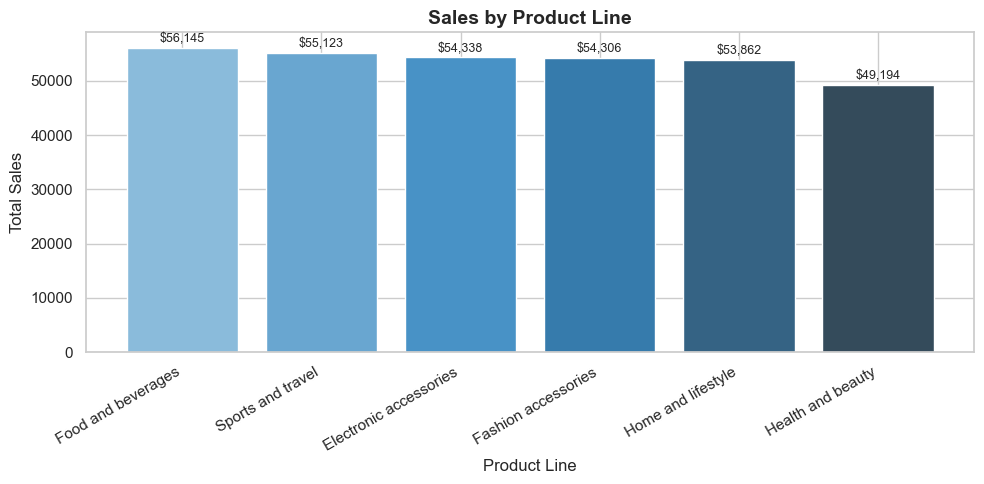


✅ Eng ko'p sotuv: Food and beverages — $56,144.84


In [6]:
# ============================================================
# 4. MAHSULOT LINIYASI BO'YICHA SOTUV
# ============================================================
sales_by_product = (
    df.groupby("Product line")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()
bars = ax.bar(sales_by_product.index, sales_by_product.values, color=sns.color_palette("Blues_d", len(sales_by_product)))
ax.set_title("Sales by Product Line", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Sales")
ax.set_xlabel("Product Line")
plt.xticks(rotation=30, ha="right")

# Har bir ustun ustiga qiymat yoz
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("images/sales_by_product.png", bbox_inches="tight")
plt.show()

# Tahlil
top_product = sales_by_product.index[0]
print(f"\n✅ Eng ko'p sotuv: {top_product} — ${sales_by_product.iloc[0]:,.2f}")

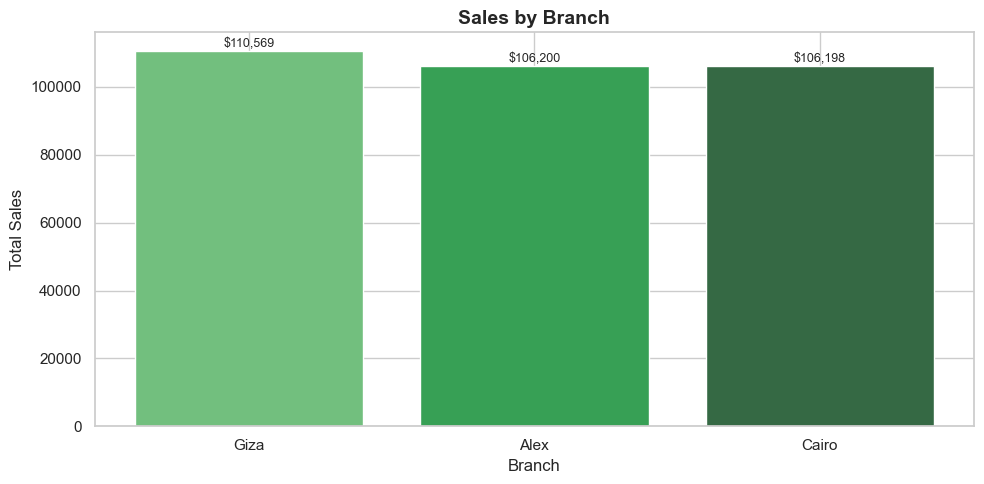


✅ Eng yuqori daromadli filial: Branch Giza — $110,568.71


In [7]:
# ============================================================
# 5. FILIAL BO'YICHA SOTUV
# ============================================================
branch_sales = (
    df.groupby("Branch")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()
bars = ax.bar(branch_sales.index, branch_sales.values, color=sns.color_palette("Greens_d", len(branch_sales)))
ax.set_title("Sales by Branch", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Sales")
ax.set_xlabel("Branch")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("images/branch_sales.png", bbox_inches="tight")
plt.show()

top_branch = branch_sales.index[0]
print(f"\n✅ Eng yuqori daromadli filial: Branch {top_branch} — ${branch_sales.iloc[0]:,.2f}")

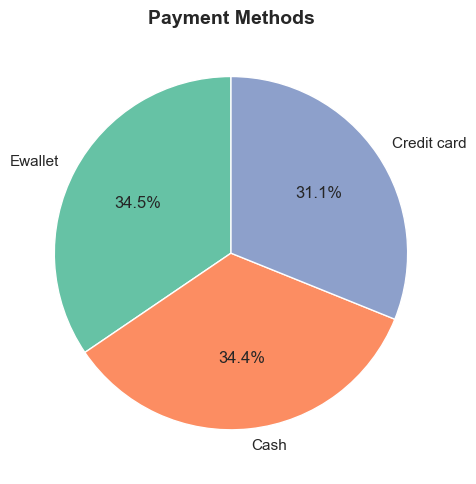


✅ Eng mashhur to'lov usuli: Ewallet (345 ta mijoz)


In [8]:
# ============================================================
# 6. TO'LOV USULLARI
# ============================================================
payment_count = df["Payment"].value_counts()

fig, ax = plt.subplots()
ax.pie(payment_count.values,
       labels=payment_count.index,
       autopct="%1.1f%%",
       colors=sns.color_palette("Set2"),
       startangle=90)
ax.set_title("Payment Methods", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("images/payment_methods.png", bbox_inches="tight")
plt.show()

top_payment = payment_count.index[0]
print(f"\n✅ Eng mashhur to'lov usuli: {top_payment} ({payment_count.iloc[0]} ta mijoz)")

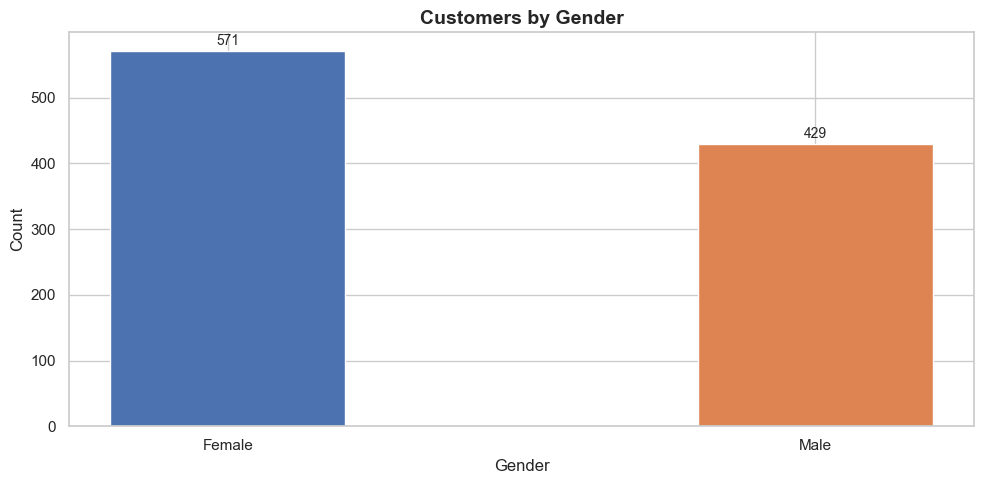


✅ Ayollar: 571 | Erkaklar: 429


In [9]:
# ============================================================
# 7. JINS BO'YICHA MIJOZLAR
# ============================================================
gender_count = df["Gender"].value_counts()

fig, ax = plt.subplots()
bars = ax.bar(gender_count.index, gender_count.values,
              color=["#4C72B0", "#DD8452"], width=0.4)
ax.set_title("Customers by Gender", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("Gender")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("images/gender_count.png", bbox_inches="tight")
plt.show()

print(f"\n✅ Ayollar: {gender_count.get('Female', 0)} | Erkaklar: {gender_count.get('Male', 0)}")

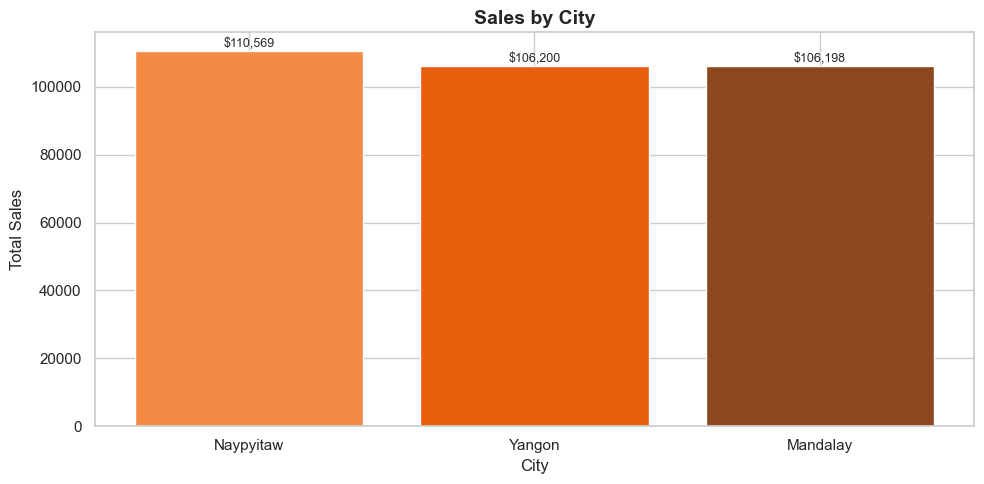


✅ Eng ko'p sotuv shahri: Naypyitaw — $110,568.71


In [10]:
# ============================================================
# 8. SHAHAR BO'YICHA SOTUV
# ============================================================
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()
bars = ax.bar(city_sales.index, city_sales.values,
              color=sns.color_palette("Oranges_d", len(city_sales)))
ax.set_title("Sales by City", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Sales")
ax.set_xlabel("City")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("images/sales_by_city.png", bbox_inches="tight")
plt.show()

top_city = city_sales.index[0]
print(f"\n✅ Eng ko'p sotuv shahri: {top_city} — ${city_sales.iloc[0]:,.2f}")

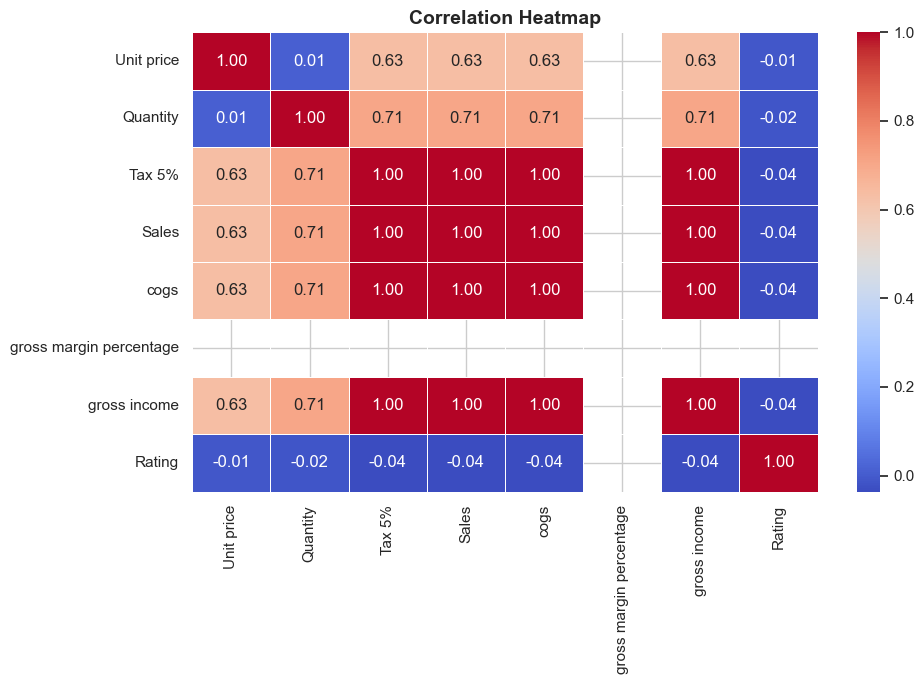

In [11]:
# ============================================================
# 9. KORRELYATSIYA HEATMAP
# ============================================================
numeric_cols = df.select_dtypes(include="number")

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax, linewidths=0.5)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", bbox_inches="tight")
plt.show()

C:\Users\Behzod\AppData\Local\Temp\ipykernel_5376\788628856.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


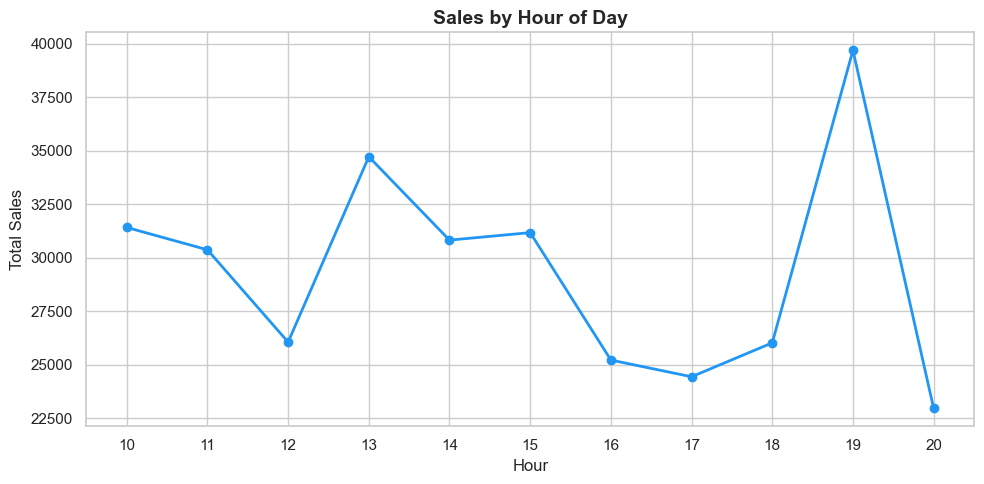


✅ Eng gavjum soat: 19:00


In [12]:
# ============================================================
# 10. SOAT BO'YICHA SOTUV (Qaysi vaqt gavjum?)
# ============================================================
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour
hourly_sales = df.groupby("Hour")["Sales"].sum()

fig, ax = plt.subplots()
ax.plot(hourly_sales.index, hourly_sales.values, marker="o", color="#2196F3", linewidth=2)
ax.set_title("Sales by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour")
ax.set_ylabel("Total Sales")
ax.set_xticks(hourly_sales.index)

plt.tight_layout()
plt.savefig("images/sales_by_hour.png", bbox_inches="tight")
plt.show()

peak_hour = hourly_sales.idxmax()
print(f"\n✅ Eng gavjum soat: {peak_hour}:00")

In [13]:
# ============================================================
# 11. XULOSALAR (Datadan olingan haqiqiy natijalar)
# ============================================================
print("=" * 50)
print("📊 XULOSALAR")
print("=" * 50)
print(f"1. Eng ko'p sotiladigan mahsulot: {top_product}")
print(f"2. Eng yuqori daromadli filial: Branch {top_branch}")
print(f"3. Eng mashhur to'lov usuli: {top_payment}")
print(f"4. Mijozlar jinsi: Ayollar {gender_count.get('Female',0)}, Erkaklar {gender_count.get('Male',0)}")
print(f"5. Eng ko'p sotuv shahri: {top_city}")
print(f"6. Savdo cho'qqisi soati: {peak_hour}:00")
print("=" * 50)

📊 XULOSALAR
1. Eng ko'p sotiladigan mahsulot: Food and beverages
2. Eng yuqori daromadli filial: Branch Giza
3. Eng mashhur to'lov usuli: Ewallet
4. Mijozlar jinsi: Ayollar 571, Erkaklar 429
5. Eng ko'p sotuv shahri: Naypyitaw
6. Savdo cho'qqisi soati: 19:00
